In [1]:
import sys
sys.path.append('../src/')
import numpy as onp
import h5py

from plot_utils import make_corner_plot, make_amplitude_ratio_plot, make_amp_ratio_tshifts_plot

This notebook reproduces all the plots from the paper. We analyze two events - GW250114 and GW190521. For GW250114, we use three different approaches - FULL-SKY, FIXED-SKY, INFORMED-SKY, while for GW190521 we discard the last one (see paper). Also presented are the mode amplitude ratios for the two events using the various methods, and its variation with time. 

Additionally, we study two test cases where we analyze simulated ringdown signals, and compare the FULL-SKY and FIXED-sky methods.

NOTE: This notebook uses saved samples from previous runs. To generate the posterior samples, run the associated files (see README).

# GW250114

### (221+220) model

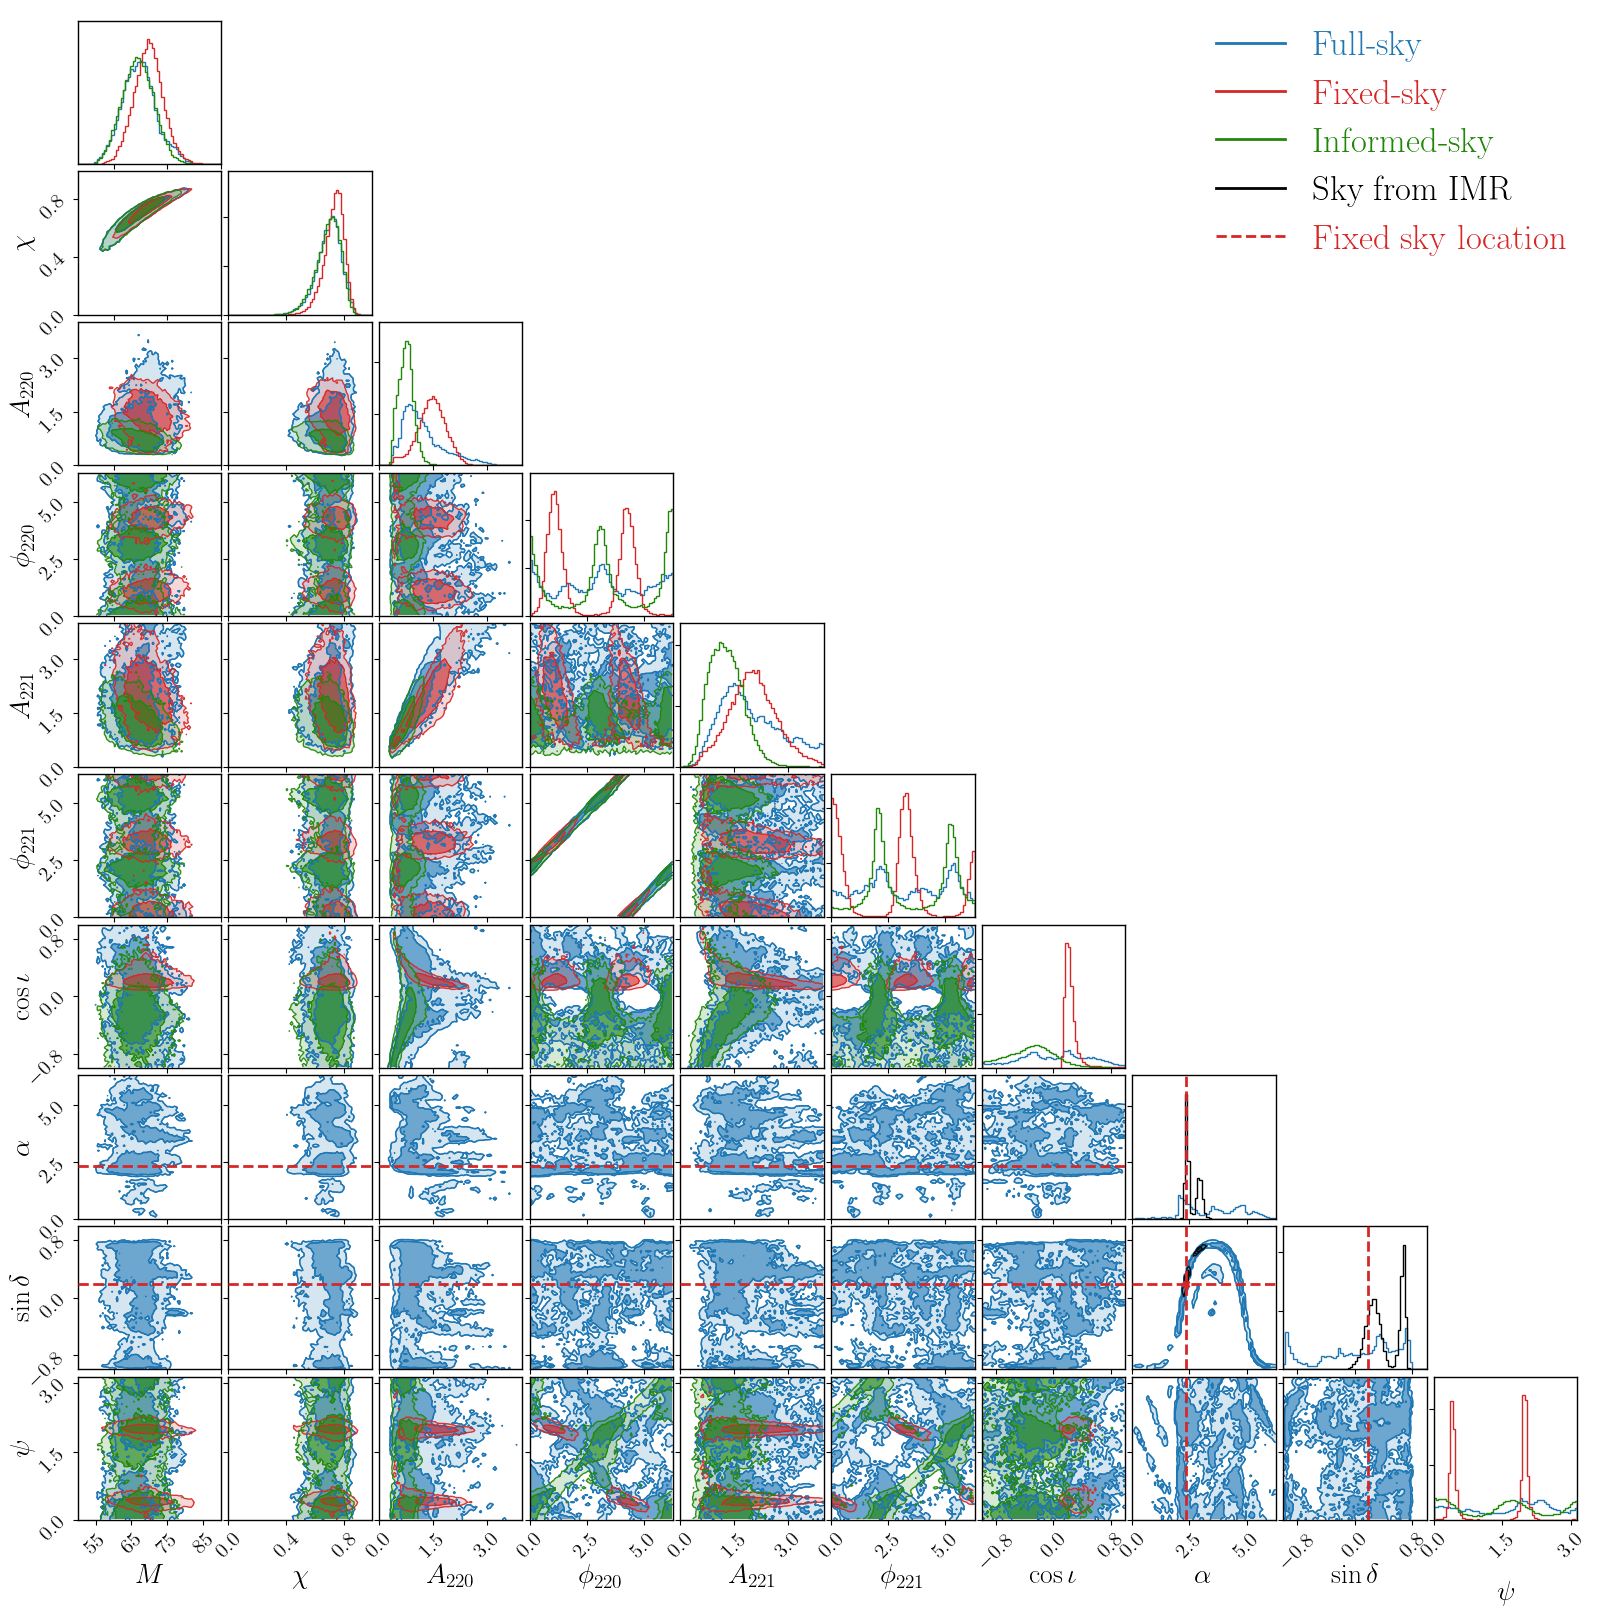

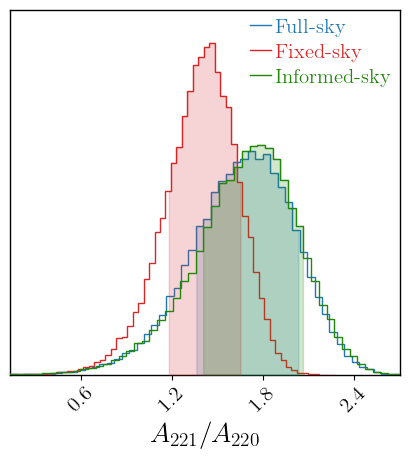

/Users/kallol/Work/skyRing/examples/../src/plot_utils.py:719: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


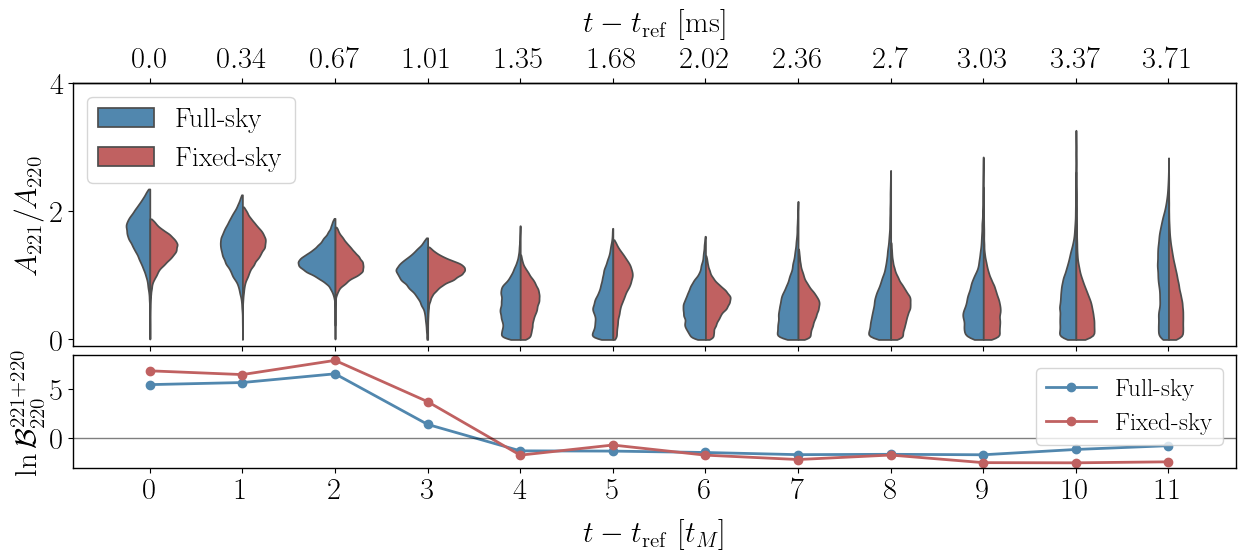

In [2]:
event_id = "GW250114"
IMR_samples_file = "GW250114_posterior_samples_NRSur7dq4.h5"
posteriors_dir = "./posterior_files/"

## Sky location for FIXED-SKY
ra, dec = 2.33, 0.19

full_sky_params = [ r'$M$', r'$\chi$', r'$A_{220}$', r'$\phi_{220}$', r'$A_{221}$', r'$\phi_{221}$', r'$\cos\iota$', r'$\alpha$', r'$\sin \delta$', r'$\psi$' ]
fixed_sky_params = [ r'$M$', r'$\chi$', r'$A_{220}$', r'$\phi_{220}$', r'$A_{221}$', r'$\phi_{221}$', r'$\cos\iota$', r'$\psi$' ]
sky_params = [r'$\alpha$', r'$\sin \delta$']

## Load saved samples
posterior_full_sky  = onp.load(posteriors_dir + 'full-sky/posterior.' + event_id + '.full-sky.npy')
posterior_fixed_sky = onp.load(posteriors_dir + 'fixed-sky/posterior.' + event_id + '.fixed-sky.npy')
posterior_informed_sky = onp.load(posteriors_dir + 'informed-sky/posterior.' + event_id + '.informed-sky.npy')

with h5py.File(posteriors_dir + IMR_samples_file, "r") as f:
    post_samples = f['bilby-NRSur7dq4_prod-reweighted']['posterior_samples'][:]
ra_imr = post_samples['ra']
sindec_imr = onp.sin(post_samples['dec'])
samples_IMR = onp.array([ra_imr, sindec_imr]).T

## Set parameter bounds for the corner plots for better visualization
bounds = {
    r'$M$': (50.0, 90.0),
    r'$A_{220}$': (0.0, 4.0),
    r'$A_{221}$': (0.0, 4.0),
}

## Plotter accepts samples as datasets
datasets = [{"samples": posterior_full_sky,
            "params": full_sky_params,
            "label": "Full-sky",
            "color": "#1f77b4"},

            {"samples": posterior_fixed_sky,
            "params": fixed_sky_params,
            "label": "Fixed-sky",
            "color": "#d62728"},

            {"samples": posterior_informed_sky,
            "params": fixed_sky_params,
            "label": "Informed-sky",
            "color": "#218709"},

            {"samples": samples_IMR,
            "params": sky_params,
            "label": "Sky from IMR",
            "color": "#000000"}]

## Make corner plot with comparison between different methods of treating sky location
make_corner_plot(datasets=datasets, full_sky_params=full_sky_params, truths=None,
                 fixed_sky_location={"alpha": ra, "sin_delta": onp.sin(dec), "color": "#d62728", "label": "Fixed sky location"},
                 tick_overrides={
                     (-1, 0): {"x": [55.0, 65.0, 75.0, 85.0]},
                     },
                 savepath="./plots/GW250114.pdf",
                 )

## Amplitude ratio (A221/A220)
make_amplitude_ratio_plot(datasets=datasets[:-1], numerator_index=4, denominator_index=2, 
                          ratio_label=r'$A_{221}/A_{220}$', bins=60, 
                          savepath='./plots/GW250114_amp_ratio.pdf',
)

## Amplitude ratio (A221/A220) across time
make_amp_ratio_tshifts_plot(event_id=event_id,
                            full_dir=posteriors_dir + "full-sky/" + event_id + "-t-shift-posteriors",
                            fixed_dir=posteriors_dir + "fixed-sky/" + event_id + "-t-shift-posteriors",
                            full_220_dir=posteriors_dir + "full-sky/" + event_id + "-220-t-shift-posteriors",
                            fixed_220_dir=posteriors_dir + "fixed-sky/" + event_id + "-220-t-shift-posteriors",
                            ratio_label=r"$A_{221}/A_{220}$",
                            logb_label=r"$\ln \mathcal{B}^{221+220}_{220}$",
                            trim=(0.00, 0.99),
                            ylim=(-0.1, 4),
                            savepath="./plots/GW250114_amp_ratio_tshifts_with_logB.pdf",
                            )

# GW190521

### (330+220) model

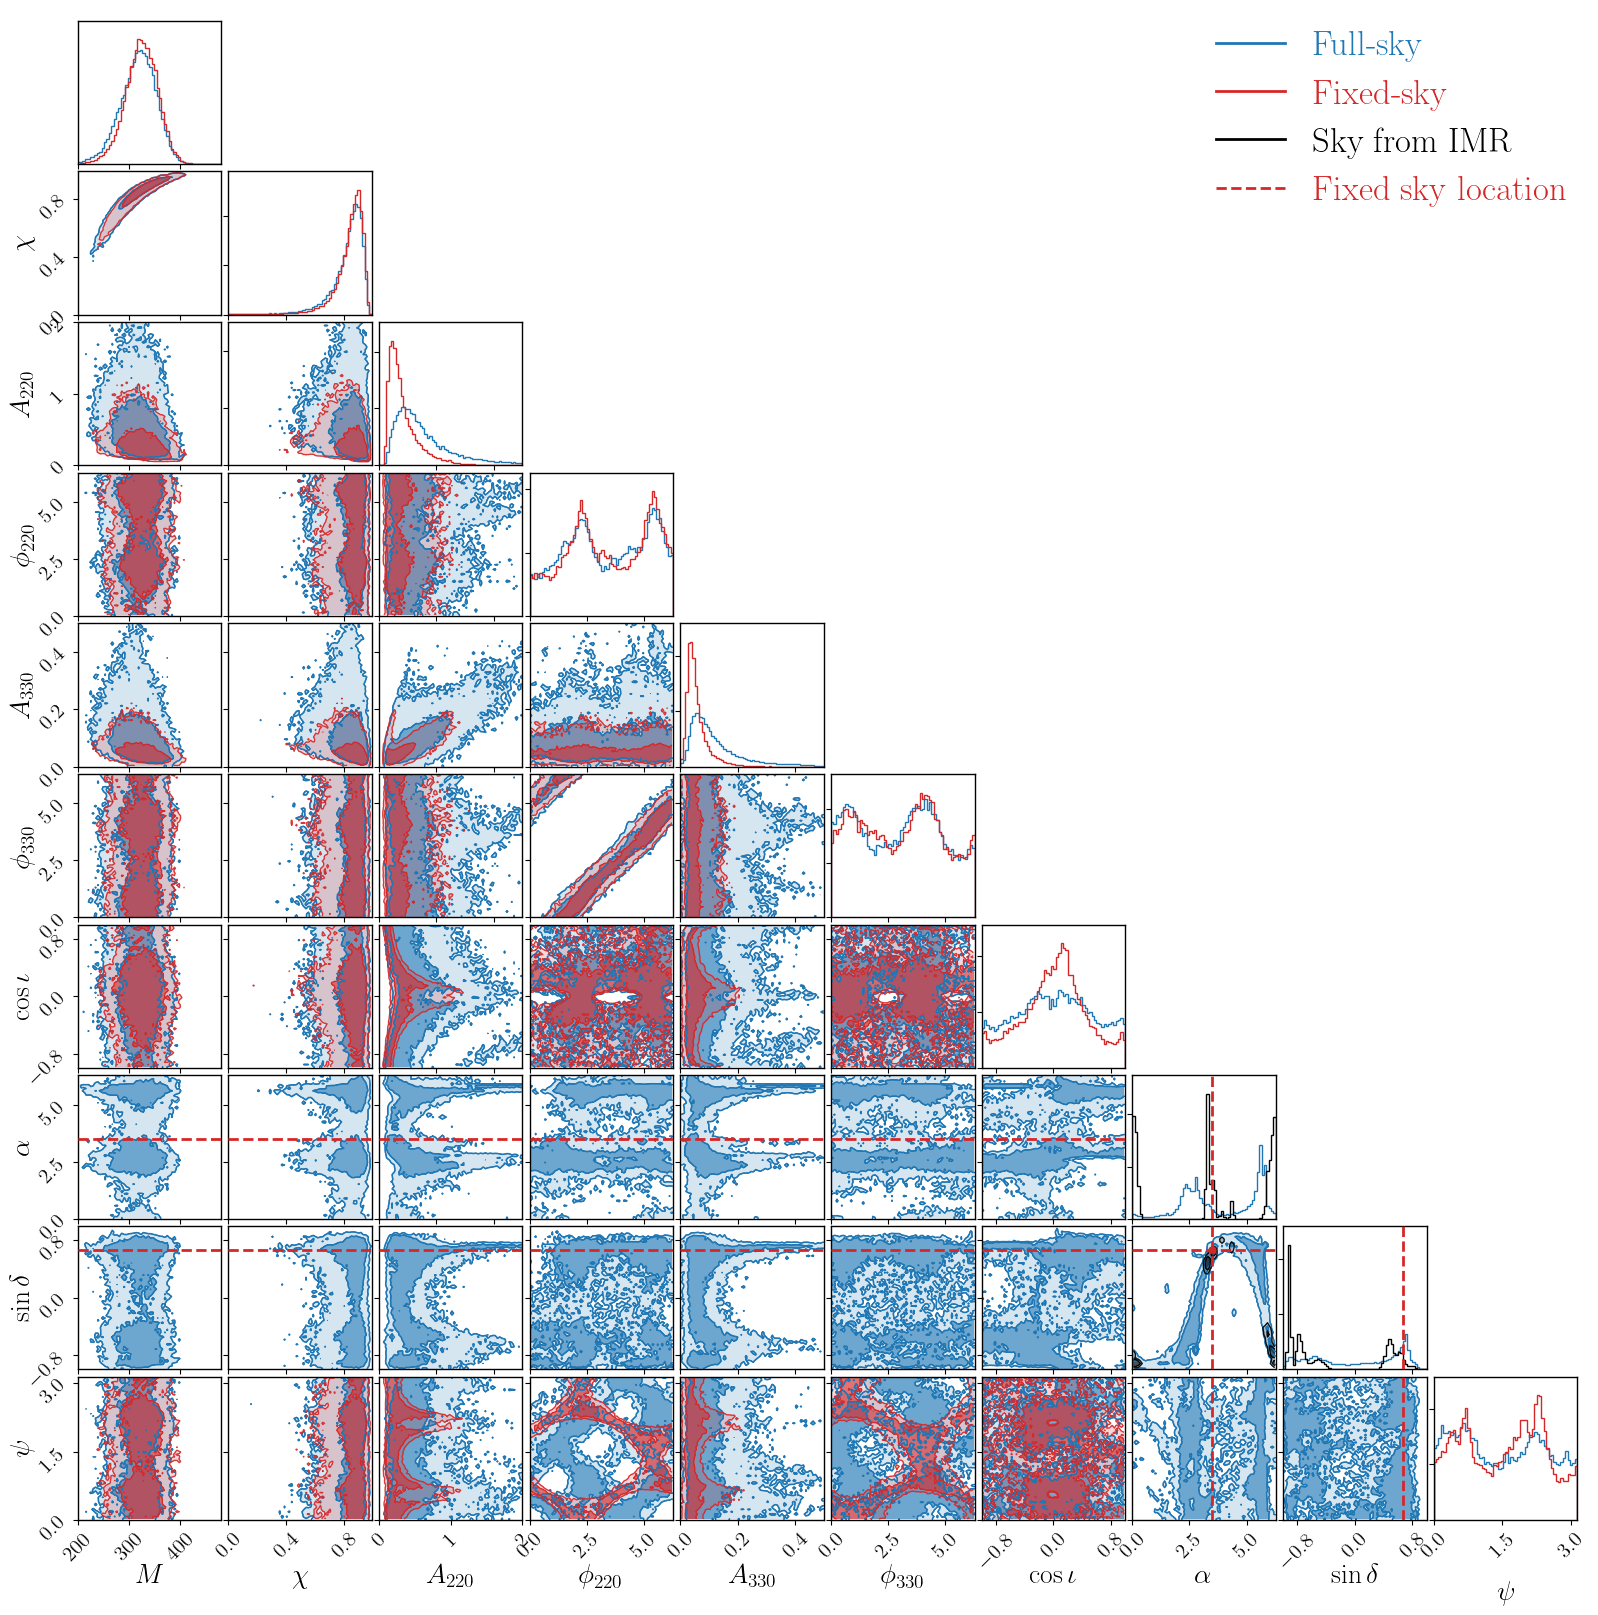

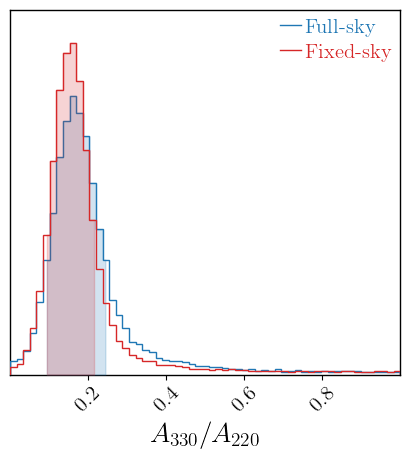

/Users/kallol/Work/skyRing/examples/../src/plot_utils.py:719: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


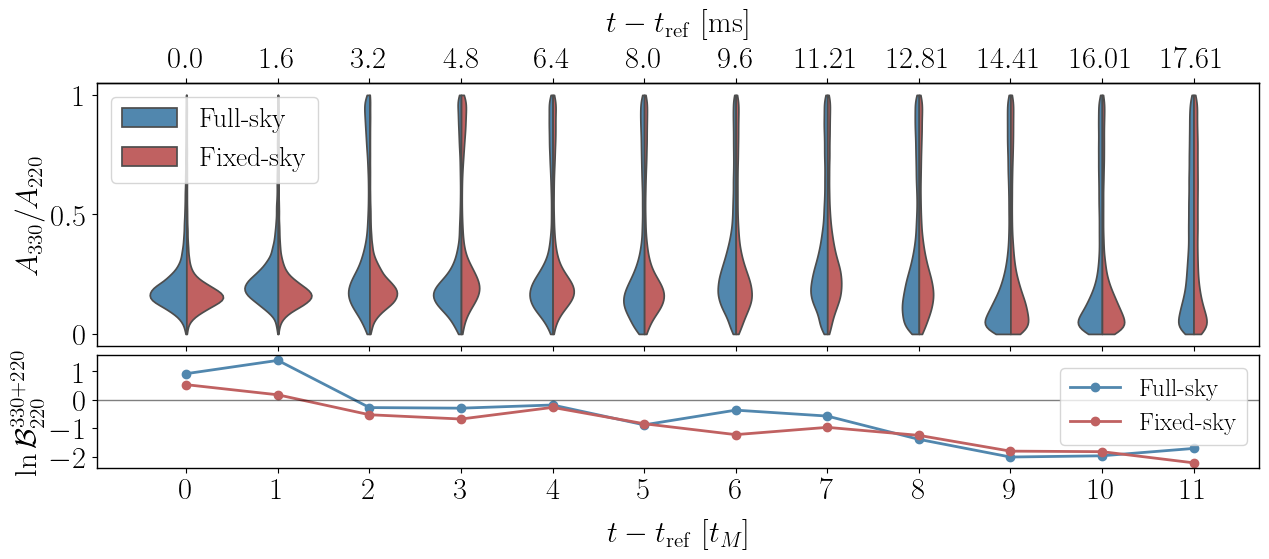

In [6]:
event_id = "GW190521"
IMR_samples_file = "GW190521_posterior_samples.h5"
posteriors_dir = "./posterior_files/"

## Sky location for FIXED-SKY
ra, dec = 3.5, 0.73

full_sky_params = [ r'$M$', r'$\chi$', r'$A_{220}$', r'$\phi_{220}$', r'$A_{330}$', r'$\phi_{330}$', r'$\cos\iota$', r'$\alpha$', r'$\sin \delta$', r'$\psi$']
fixed_sky_params = [ r'$M$', r'$\chi$', r'$A_{220}$', r'$\phi_{220}$', r'$A_{330}$', r'$\phi_{330}$', r'$\cos\iota$', r'$\psi$']
sky_params = [r'$\alpha$', r'$\sin \delta$']

## Load saved samples
posterior_full_sky  = onp.load(posteriors_dir + 'full-sky/posterior.' + event_id + '.full-sky.npy')
posterior_fixed_sky = onp.load(posteriors_dir + 'fixed-sky/posterior.' + event_id + '.fixed-sky.npy')

with h5py.File("./posterior_files/" + IMR_samples_file, "r") as f:
    post_samples = f['NRSur7dq4']['posterior_samples'][:]
ra_imr = post_samples['ra']
sindec_imr = onp.sin(post_samples['dec'])
samples_IMR = onp.array([ra_imr, sindec_imr]).T


## Set parameter bounds for the corner plots for better visualization
bounds = {
        r'$M$': (200.0, 480.0),
        r'$A_{220}$': (0.0, 2.0),
        r'$A_{330}$': (0.0, 0.5),
        }


## Plotter accepts samples as datasets
datasets = [{"samples": posterior_full_sky,
            "params": full_sky_params,
            "label": "Full-sky",
            "color": "#1f77b4"},

            {"samples": posterior_fixed_sky,
            "params": fixed_sky_params,
            "label": "Fixed-sky",
            "color": "#d62728"},

            {"samples": samples_IMR,
            "params": sky_params,
            "label": "Sky from IMR",
            "color": "#000000"}]

## Make corner plot with comparison between different methods of treating sky location
make_corner_plot(datasets=datasets, full_sky_params=full_sky_params, truths=None, bounds=bounds,
                fixed_sky_location={"alpha": ra, "sin_delta": onp.sin(dec), "color": "#d62728", "label": "Fixed sky location",},
                tick_overrides={
                    # (-1, 4): {"x": [0.0, 0.5, 1.0]},
                    (-1, 2): {"x": [0.0, 1.0, 2.0]},
                    # (4, 0): {"y": [0.0, 0.5, 1.0]},
                    (2, 0): {"y": [0.0, 1.0, 2.0]},
                },
                savepath="./plots/GW190521.pdf",
                )

## Amplitude ratio (A330/A220)
make_amplitude_ratio_plot(datasets=datasets[:-1], numerator_index=4, denominator_index=2, 
                          ratio_label=r'$A_{330}/A_{220}$', bins=60, 
                          savepath='./plots/GW190521_amp_ratio.pdf',
)

## Amplitude ratio (A330/A220) across time
make_amp_ratio_tshifts_plot(event_id=event_id,
                            full_dir=posteriors_dir + "full-sky/" + event_id + "-t-shift-posteriors",
                            fixed_dir=posteriors_dir + "fixed-sky/" + event_id + "-t-shift-posteriors",
                            full_220_dir=posteriors_dir + "full-sky/" + event_id + "-220-t-shift-posteriors",
                            fixed_220_dir=posteriors_dir + "fixed-sky/" + event_id + "-220-t-shift-posteriors",
                            ratio_label=r"$A_{330}/A_{220}$",
                            logb_label=r"$\ln \mathcal{B}^{330+220}_{220}$",
                            bf_yticks=[-2, -1, 0, 1],
                            savepath="./plots/GW190521_amp_ratio_tshifts_with_logB.pdf",
)

# Simulation (221+220)

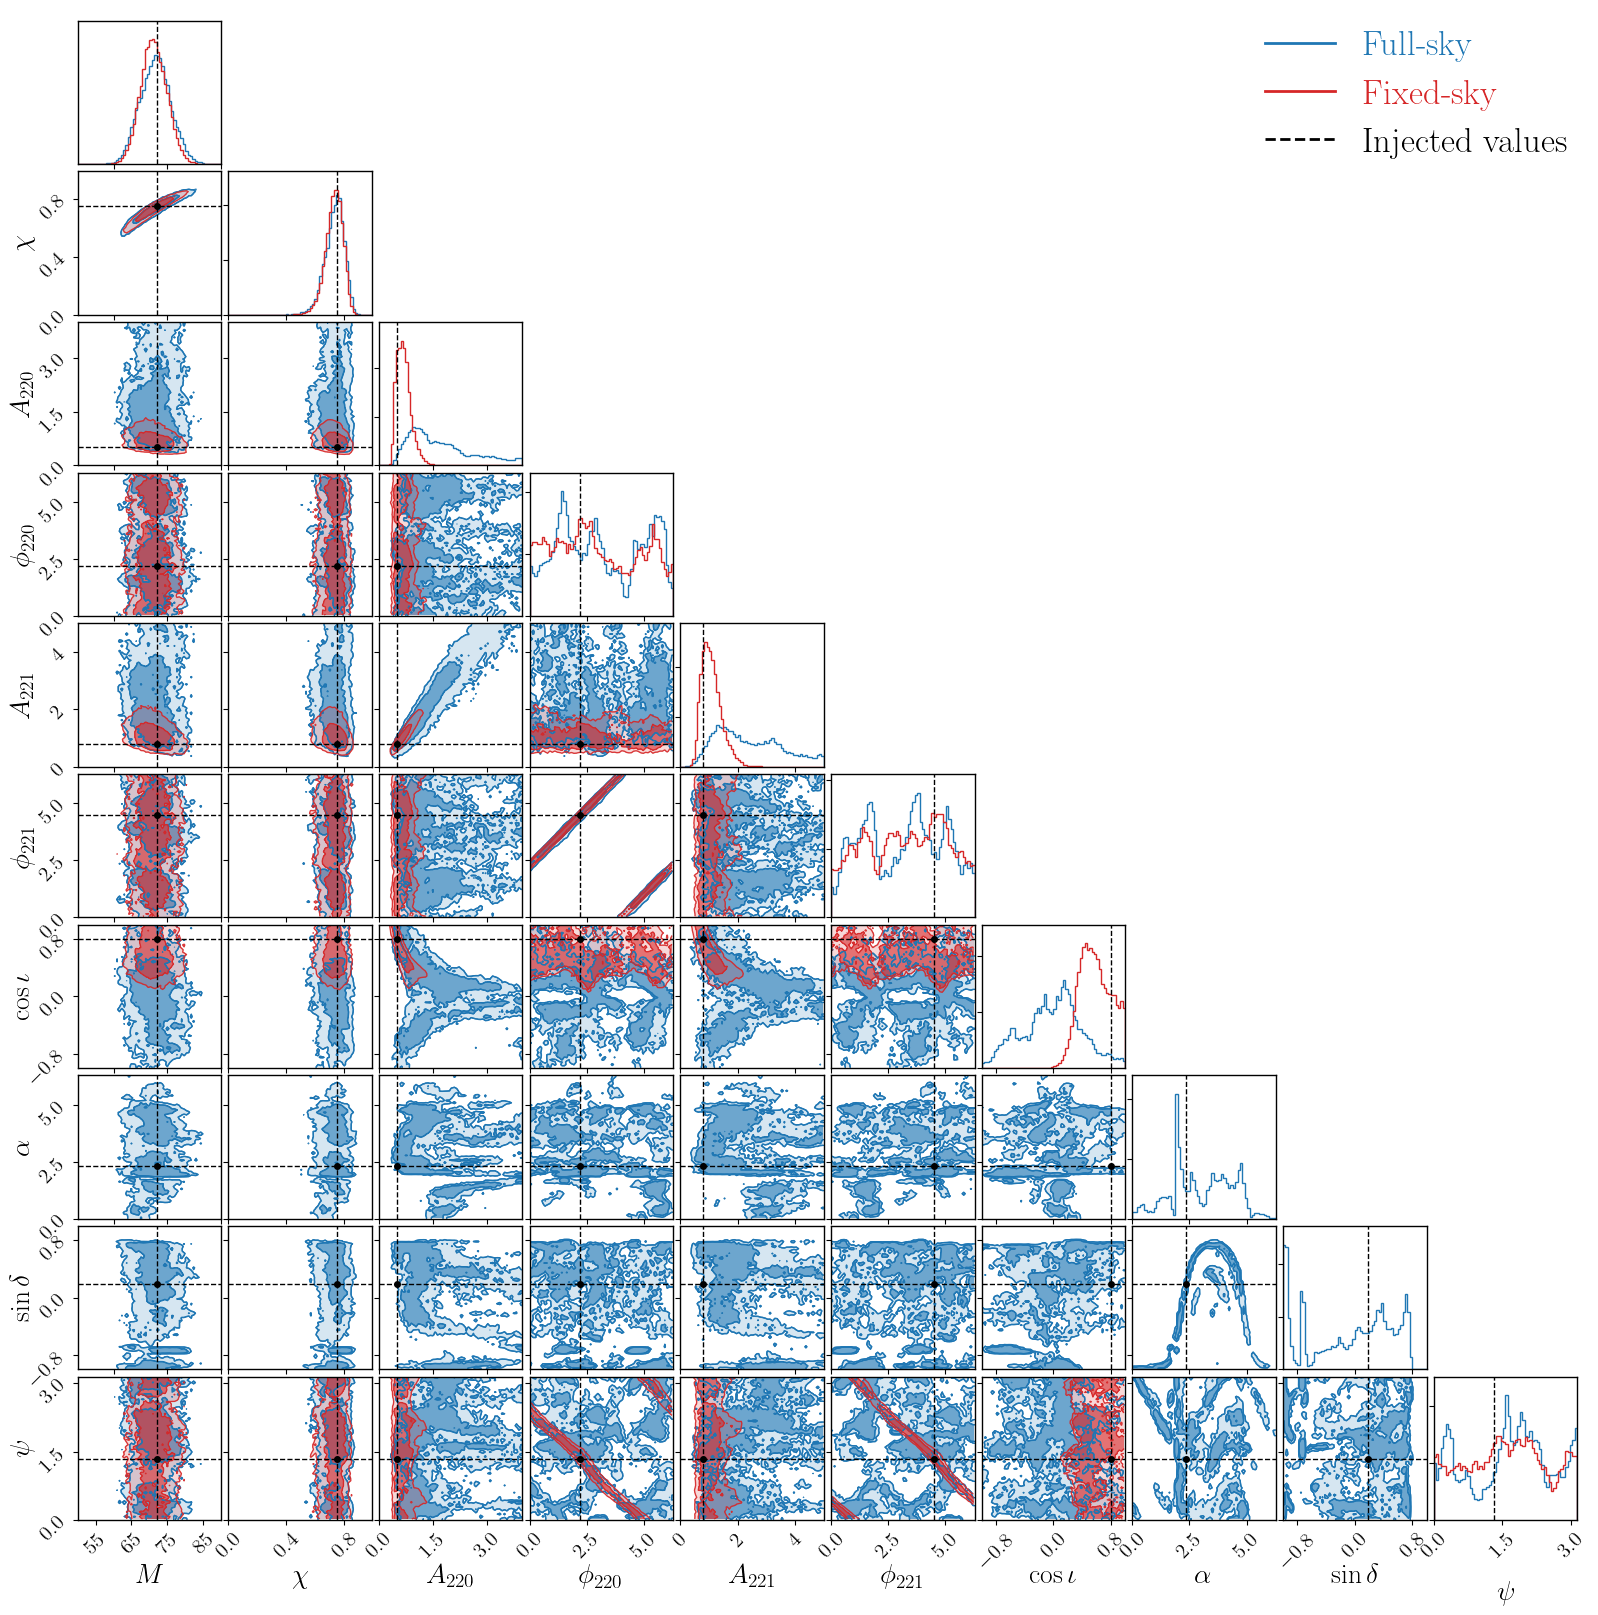

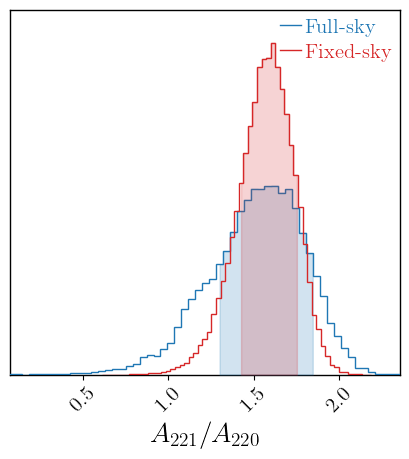

In [4]:
full_sky_params = [ r'$M$', r'$\chi$', r'$A_{220}$', r'$\phi_{220}$', r'$A_{221}$', r'$\phi_{221}$', r'$\cos\iota$', r'$\alpha$', r'$\sin \delta$', r'$\psi$' ]
fixed_sky_params = [ r'$M$', r'$\chi$', r'$A_{220}$', r'$\phi_{220}$', r'$A_{221}$', r'$\phi_{221}$', r'$\cos\iota$', r'$\psi$' ]

sky_params = [r'$\alpha$', r'$\sin \delta$']

posterior_full_sky  = onp.load('./posterior_files/simulations_220_221/posterior.noiseless-sim.full-sky.npy')
posterior_fixed_sky = onp.load('./posterior_files/simulations_220_221/posterior.noiseless-sim.fixed-sky.npy')

## Injection parameters
theta_GT = onp.array([72., 0.75,  0.5, 2.2, 0.8, 4.5, 0.7960838, 2.33, 0.18885889, 1.329])

## Set parameter bounds for the corner plots for better visualization
bounds = {
    r'$M$': (50.0, 90.0),
    r'$A_{220}$': (0.0, 4.0),
    r'$A_{221}$': (0.0, 5.0),
}

## Plotter accepts samples as datasets
datasets = [{"samples": posterior_full_sky,
            "params": full_sky_params,
            "label": "Full-sky",
            "color": "#1f77b4"},

            {"samples": posterior_fixed_sky,
            "params": fixed_sky_params,
            "label": "Fixed-sky",
            "color": "#d62728"}]

## Corner plot with comparison between different methods of treating sky location
make_corner_plot(datasets=datasets, full_sky_params=full_sky_params, bounds=bounds,
                 truths=theta_GT,
                 tick_overrides={
                    (-1, 0): {"x": [55.0, 65.0, 75.0, 85.0]},
                    },
                savepath="./plots/noiseless-sim-221-220.pdf",
                )

## Amplitude ratio (A221/A220)
make_amplitude_ratio_plot(datasets=datasets, numerator_index=4, denominator_index=2, 
                          ratio_label=r'$A_{221}/A_{220}$', bins=60, 
                          savepath='./plots/noiseless-sim-221-220-amp-ratio.pdf',
)

# Simulation (330 + 220)

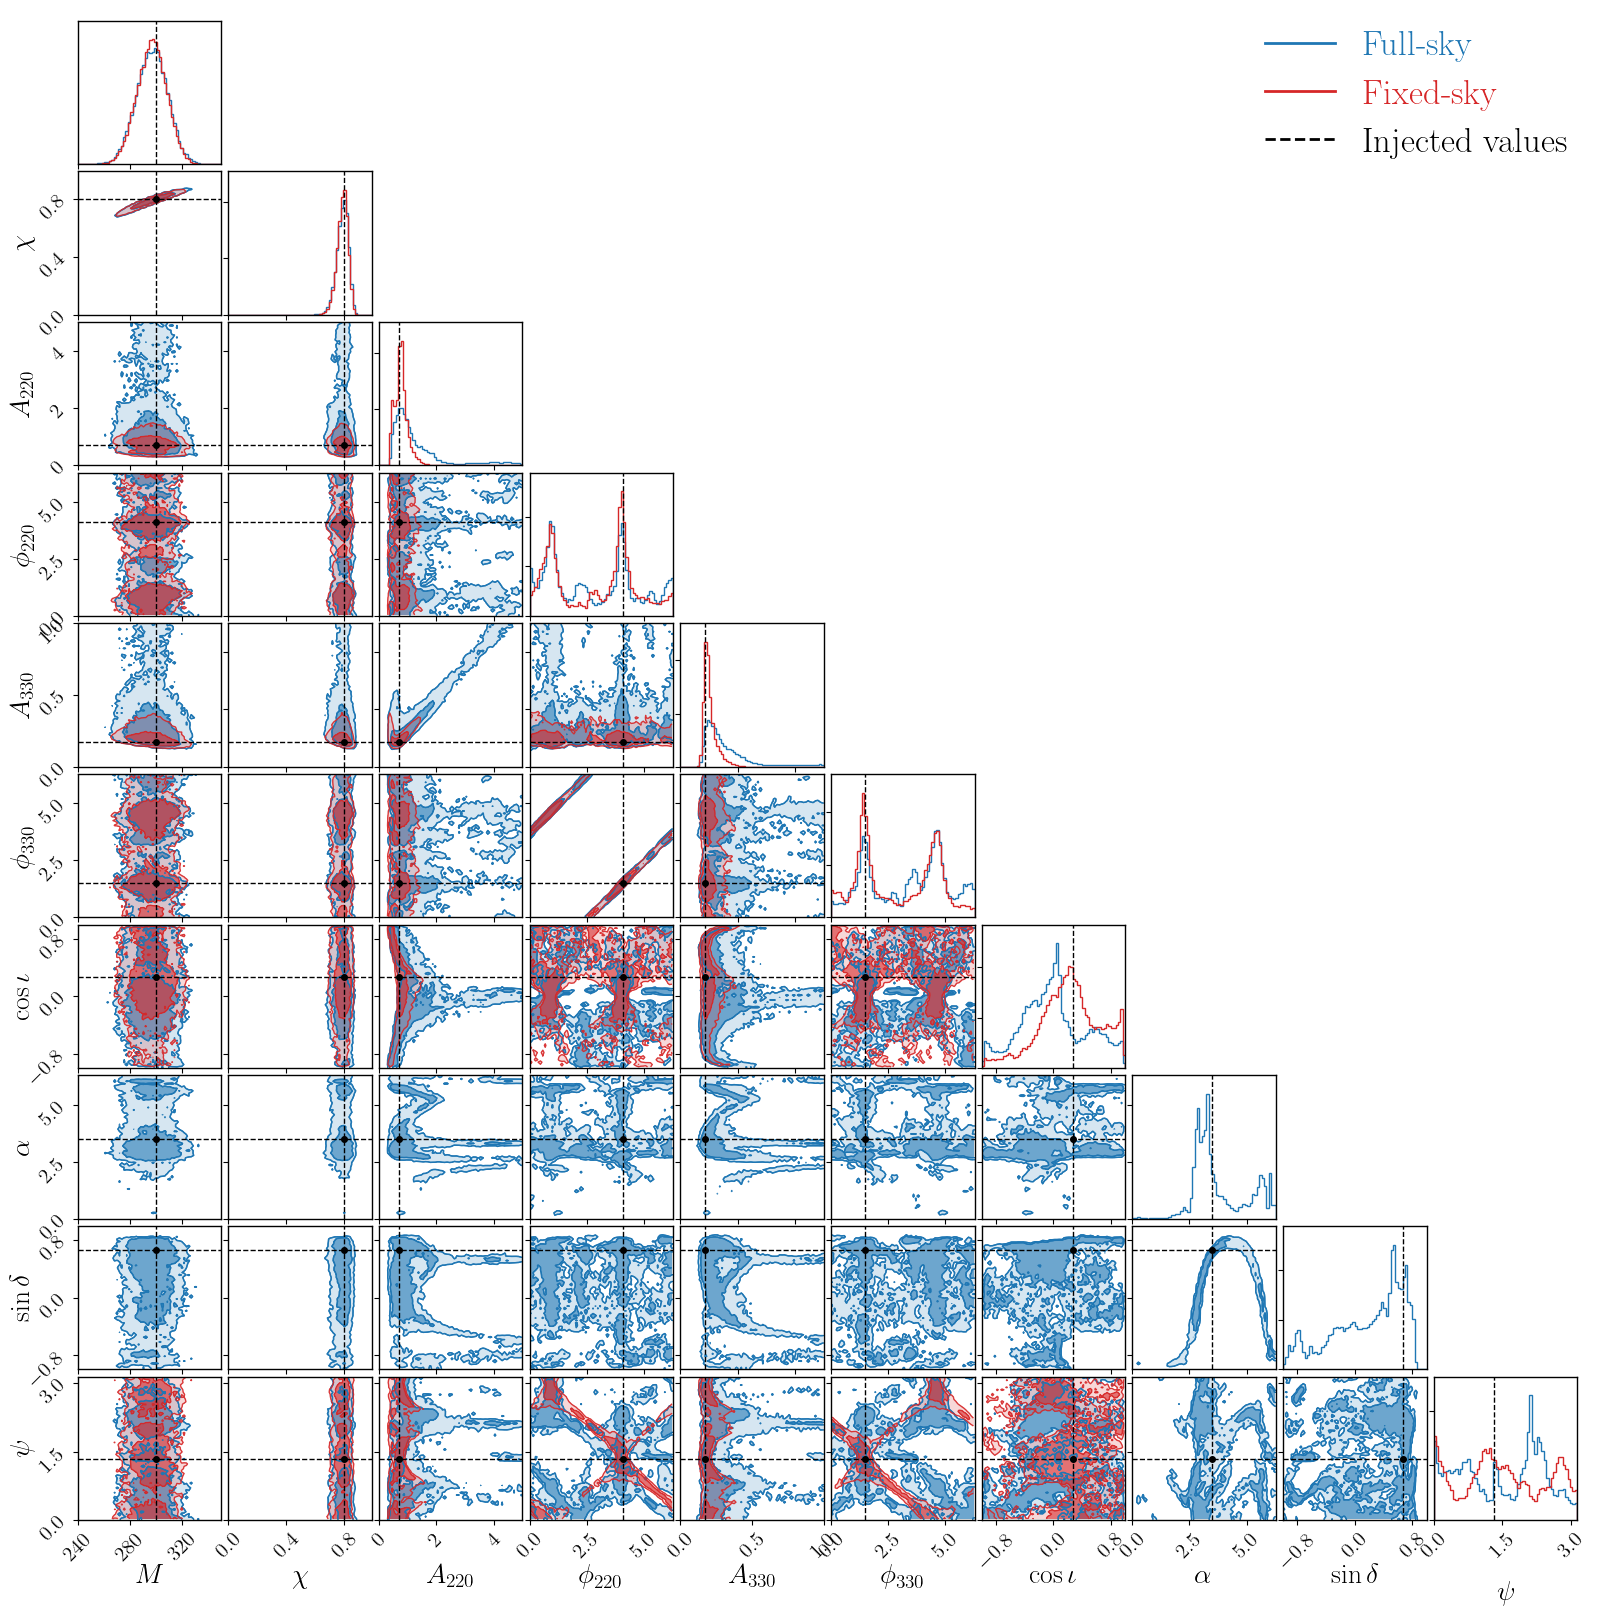

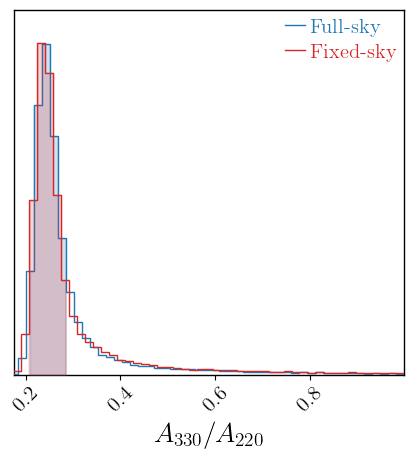

In [5]:
full_sky_params = [ r'$M$', r'$\chi$', r'$A_{220}$', r'$\phi_{220}$', r'$A_{330}$', r'$\phi_{330}$', r'$\cos\iota$', r'$\alpha$', r'$\sin \delta$', r'$\psi$' ]
fixed_sky_params = [ r'$M$', r'$\chi$', r'$A_{220}$', r'$\phi_{220}$', r'$A_{330}$', r'$\phi_{330}$', r'$\cos\iota$', r'$\psi$' ]

sky_params = [r'$\alpha$', r'$\sin \delta$']

posterior_full_sky  = onp.load('./posterior_files/simulations_220_330/posterior.noiseless-sim.full-sky.npy')
posterior_fixed_sky = onp.load('./posterior_files/simulations_220_330/posterior.noiseless-sim.fixed-sky.npy')

## Injection parameters
theta_GT = onp.array([300, 0.8, 0.7, 4.10, 0.17, 1.5, 0.27, 3.5, 0.67, 1.33] )

## Set parameter bounds for the corner plots for better visualization
bounds = {
    r'$M$': (240.0, 350.0),
    r'$A_{220}$': (0.0, 5.0),
    r'$A_{330}$': (0.0, 1.0),
}

## Plotter accepts samples as datasets
datasets = [{"samples": posterior_full_sky,
            "params": full_sky_params,
            "label": "Full-sky",
            "color": "#1f77b4"},

            {"samples": posterior_fixed_sky,
            "params": fixed_sky_params,
            "label": "Fixed-sky",
            "color": "#d62728"}]

## Corner plot with comparison between different methods of treating sky location
make_corner_plot(datasets=datasets, full_sky_params=full_sky_params, bounds=bounds,
    truths=theta_GT,
    tick_overrides={
        (-1, 4): {"x": [0.0, 0.5, 1.0]},
        (-1, 2): {"x": [0.0, 2.0, 4.0]},
        (4, 0): {"y": [0.0, 0.5, 1.0]},
        (2, 0): {"y": [0.0, 2.0, 4.0]},
    },
    savepath="./plots/noiseless-sim-330-220.pdf",
)

## Amplitude ratio (A330/A220)
make_amplitude_ratio_plot(datasets=datasets, numerator_index=4, denominator_index=2, 
                          ratio_label=r'$A_{330}/A_{220}$', bins=50, 
                          savepath='./plots/noiseless-sim-330-220-amp-ratio.pdf',
)